# Creating a Decision Trees for Iris 

**For simplicity we reduce the IRIS dataset to two dimensions.**

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

iris = datasets.load_iris()
#reducing to two dimensions
features = iris.feature_names[2:]
X = iris.data[:, 2:]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

print(features)

['petal length (cm)', 'petal width (cm)']


**Instantiation and Training**

In [31]:
from sklearn.tree import DecisionTreeClassifier
clf_tree = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=1)
clf_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=1)

**Plot the Decision Boundaries and Regions with Machine Learning Extensions**

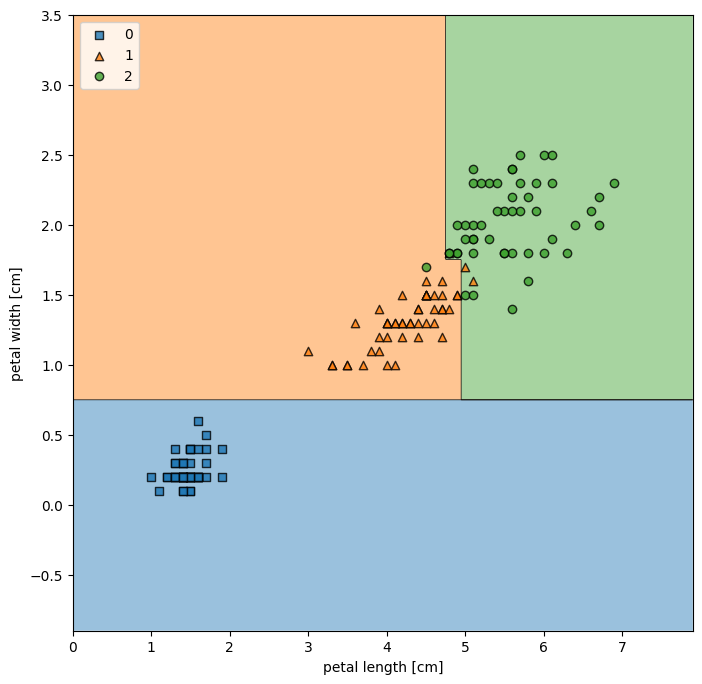

In [32]:
#!pip install mlxtend #(Short for Machine Learning Extensions)
from mlxtend.plotting import plot_decision_regions
fig, ax = plt.subplots(figsize=(8, 8))
plot_decision_regions(X, y, clf=clf_tree, hide_spines=False)
plt.xlabel('petal length [cm]')
plt.ylabel('petal width [cm]')
plt.legend(loc='upper left')


**Draw a decision Tree with sklearn function**

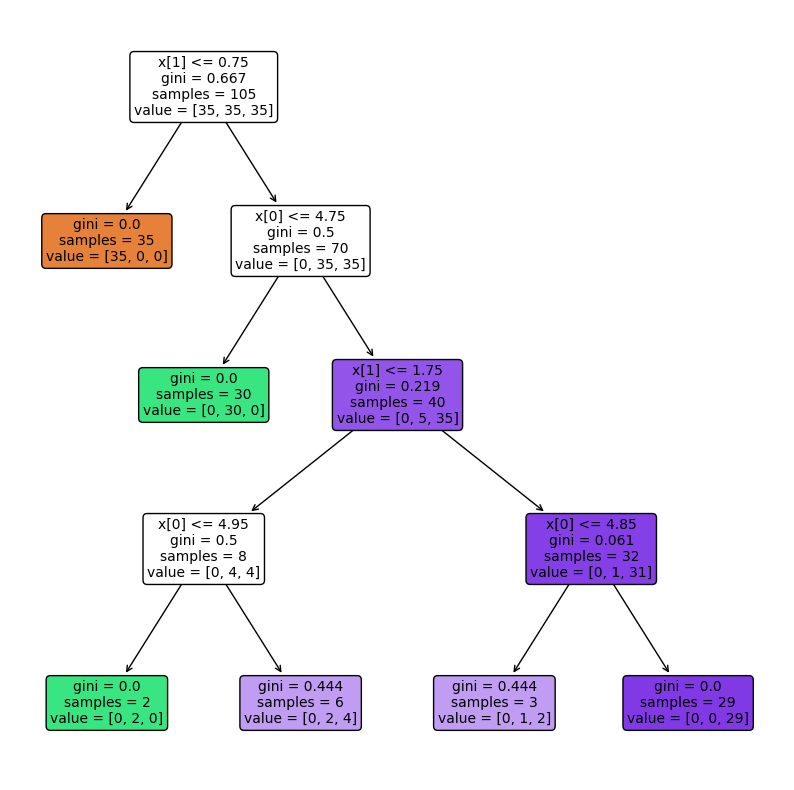

In [33]:
from sklearn import tree
fig, ax = plt.subplots(figsize=(10, 10))
tree.plot_tree(clf_tree, fontsize=10, rounded=True, filled=True)
plt.show()
# colors ---- class & degree of purity

**Draw a decision Tree with graphviz function**

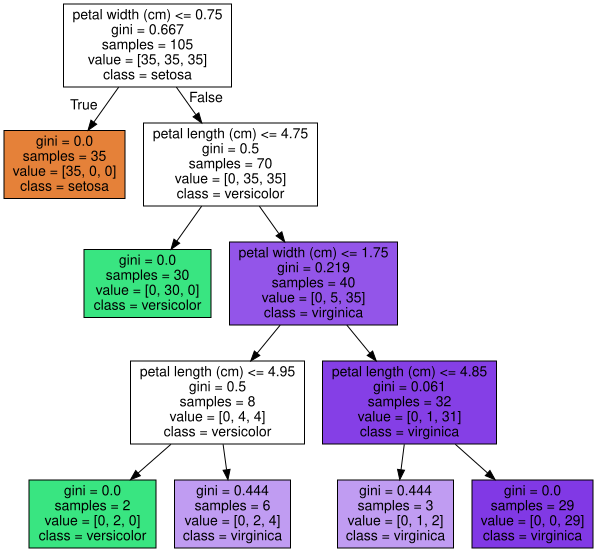

In [34]:
#On first use of Graphviz install Graphviz Binary and Python Connector
#https://graphviz.org/download/
#!pip install graphviz
import graphviz
from sklearn.tree import export_graphviz

export_graphviz(clf_tree, out_file='tree.dot', class_names=iris.target_names, feature_names=features, impurity=True, filled=True)
with open("tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

**Exercise 1: Compare algorithms on the reduced IRIS**<br>
Please tell in advance what you expect about the quality of the results compared to decision trees
1) Logistic Regression <br>
2) Support Vector Classifier<br>
3) Naive Bayes

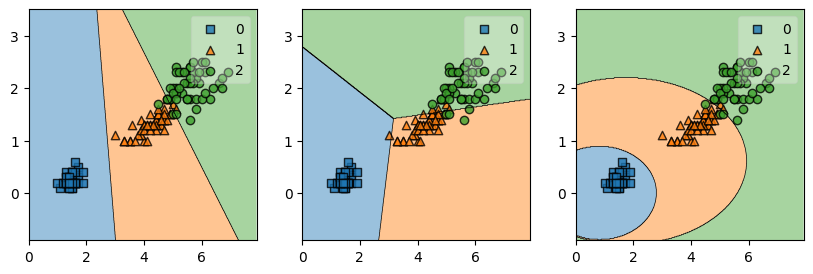

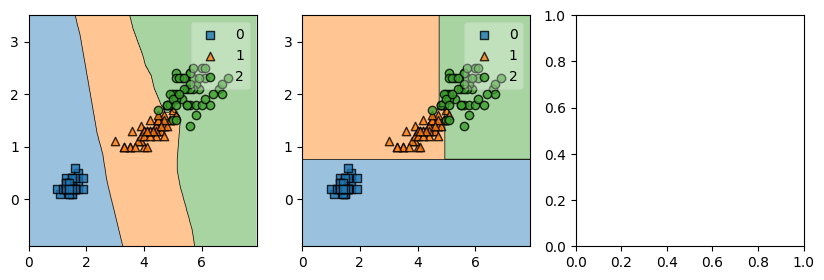

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


# Training all
clf1 = LogisticRegression().fit(X_train,y_train)
clf2 = LinearSVC(dual=False).fit(X_train,y_train)
clf3 = GaussianNB().fit(X_train, y_train)
clf4 = KNeighborsClassifier().fit(X_train, y_train)

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
plot_decision_regions(X, y, clf=clf1, hide_spines=False, ax=ax[0])
plot_decision_regions(X, y, clf=clf2, hide_spines=False, ax=ax[1])
plot_decision_regions(X, y, clf=clf3, hide_spines=False, ax=ax[2])
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
plot_decision_regions(X, y, clf=clf4, hide_spines=False, ax=ax[0])
plot_decision_regions(X, y, clf=clf_tree, hide_spines=False, ax=ax[1])
plt.show()


**Exercise 2: Apply the decision tree on the XOR Dataset**
Before you start to code predict the depth of the tree and the training accuracy!

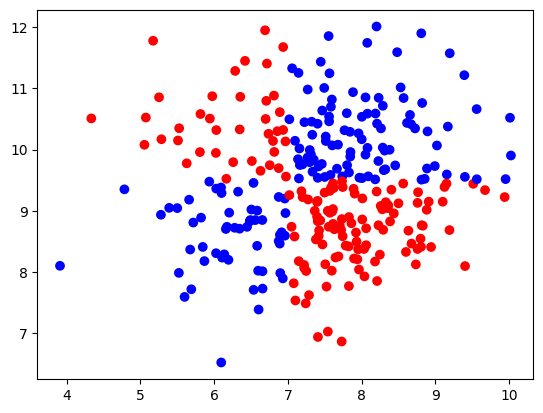

In [26]:
from sklearn.datasets import make_blobs

X,y = make_blobs(centers=1, n_samples=300, random_state=8)
y = np.logical_xor(X[:, 0] > 7, X[:, 1] > 9.5)*1
markers = marker=np.array(("b","r"))[y]
plt.scatter(X[:,0],X[:,1],c=markers)

Score 1.0


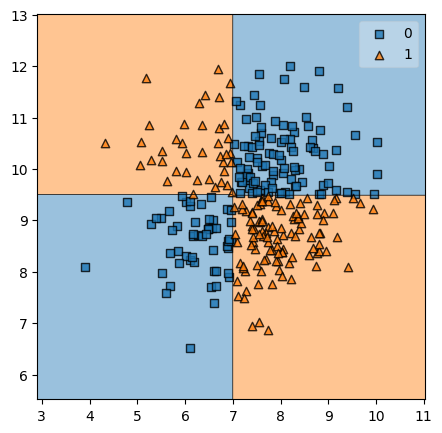

In [27]:
from sklearn.tree import DecisionTreeClassifier
clf_tree = DecisionTreeClassifier(criterion='gini', random_state=1)
clf_tree.fit(X, y)

plt.figure(figsize=(5,5))
plot_decision_regions(X, y, clf=clf_tree, hide_spines=False)

print("Score", clf_tree.score(X, y))



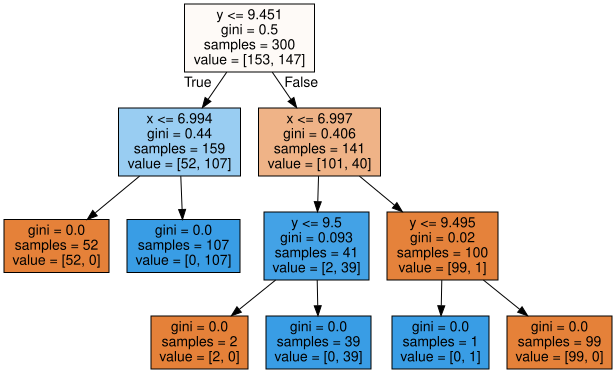

In [28]:
export_graphviz(clf_tree, out_file='tree.dot', feature_names=['x','y'], impurity=True, filled=True)
with open("tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)